In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections, re
import seaborn as sns

In [2]:
data = pd.read_csv("final_defesas_2006a2024.csv")
data_filiacao = pd.read_csv("csvs/filiacao.csv")
data_genero = pd.read_csv("csvs/genero2.csv")

## Criação de nós

In [3]:
padrao_avaliadores = 'avaliador\d$'
avaliadores = [col for col in data.columns if re.search(padrao_avaliadores, col)]
avaliadores.append("orientador")

In [60]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        grafo_defesas.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            bipartite=1 if genero == "Feminino" else 0
                            )
    n_banca -=- 1

## Criação de arestas (arestas representam colaborações em defesas de mestrado, mestrado profissional ou doutorado)

In [61]:
for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval]["qtd"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, qtd=1, ano=row[1]["ano"], tipo=row[1]["tipo"])
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [62]:
filiacao_alvo = "Universidade Estadual de Campinas"
dict_ano = nx.get_edge_attributes(grafo_defesas, name="ano")
df_dict = collections.defaultdict(list)
for person1, person2, infos in grafo_defesas.edges(data=True):
    node1 = grafo_defesas.nodes[person1]
    node2 = grafo_defesas.nodes[person2]
    df_dict["orient_filiacao_bin"].append("Unicamp" if node1['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["aval_filiacao_bin"].append("Unicamp" if node2['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["orient_genero"].append(node1["genero"])
    df_dict["aval_genero"].append(node2["genero"])
    df_dict["ano_defesa"].append(infos["ano"])
    df_dict["tipo_defesa"].append(infos["tipo"])
    # break
df = pd.DataFrame(df_dict)

<Axes: xlabel='count', ylabel='aval_filiacao_bin'>

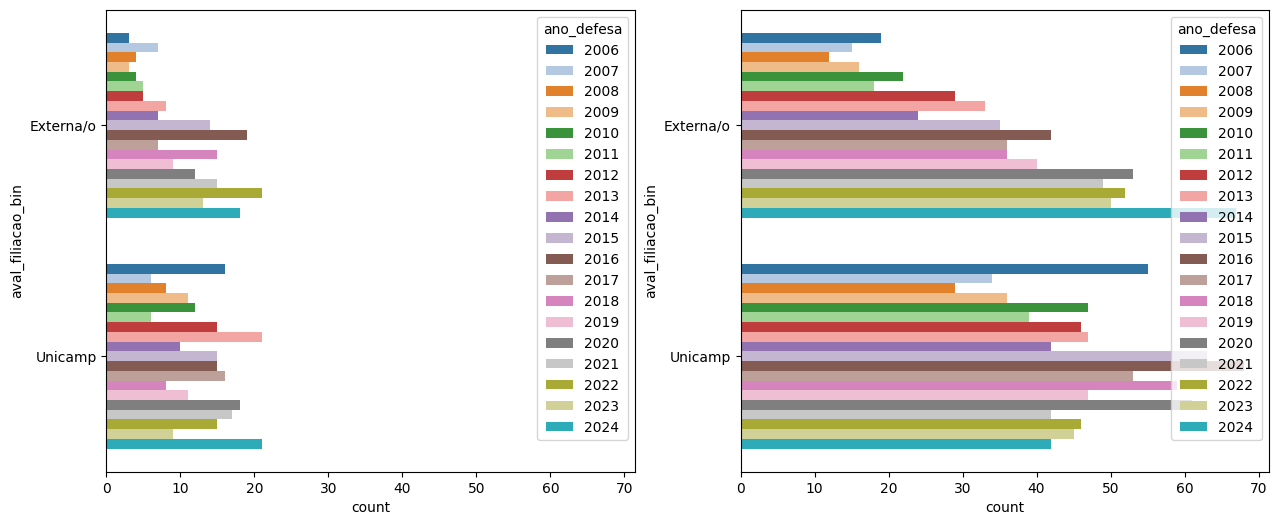

In [56]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True)

sns.countplot(df[df["aval_genero"] == "Feminino"], y="aval_filiacao_bin", hue="ano_defesa", ax=ax[0], order=("Externa/o", "Unicamp"), palette="tab20")
sns.countplot(df[df["aval_genero"] == "Masculino"], y="aval_filiacao_bin", hue="ano_defesa", ax=ax[1], order=("Externa/o", "Unicamp"), palette="tab20")

<Axes: xlabel='count', ylabel='aval_filiacao_bin'>

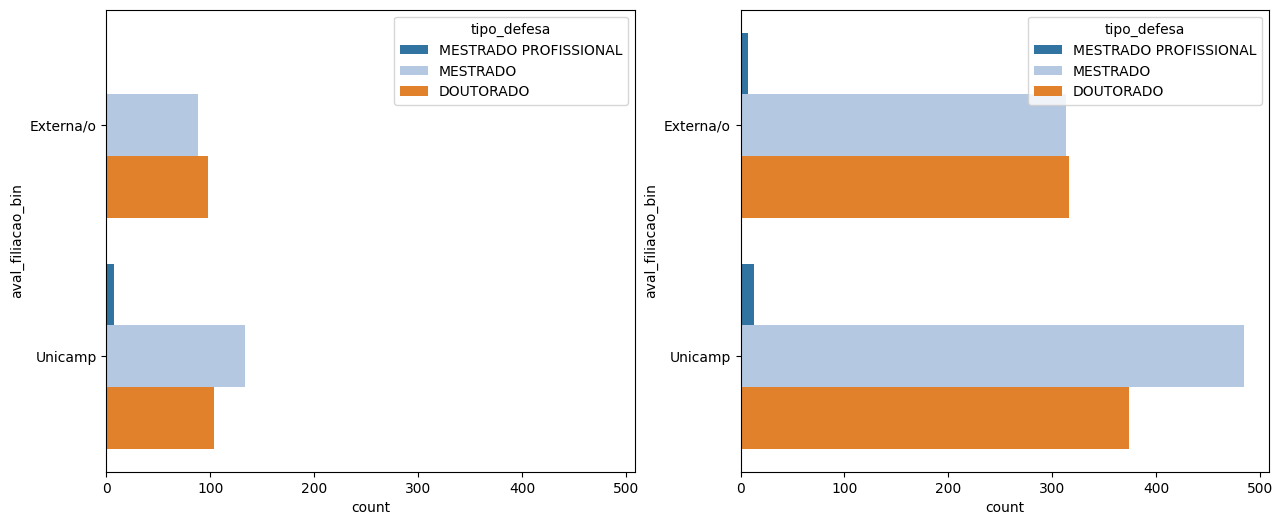

In [65]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True)
hue_order = ["MESTRADO PROFISSIONAL", "MESTRADO", "DOUTORADO"]
sns.countplot(df[df["aval_genero"] == "Feminino"], y="aval_filiacao_bin", hue="tipo_defesa", ax=ax[0], order=("Externa/o", "Unicamp"),
              palette="tab20", hue_order=hue_order)
sns.countplot(df[df["aval_genero"] == "Masculino"], y="aval_filiacao_bin", hue="tipo_defesa", ax=ax[1], order=("Externa/o", "Unicamp"),
              palette="tab20", hue_order=hue_order)

<Axes: xlabel='count', ylabel='aval_filiacao_bin'>

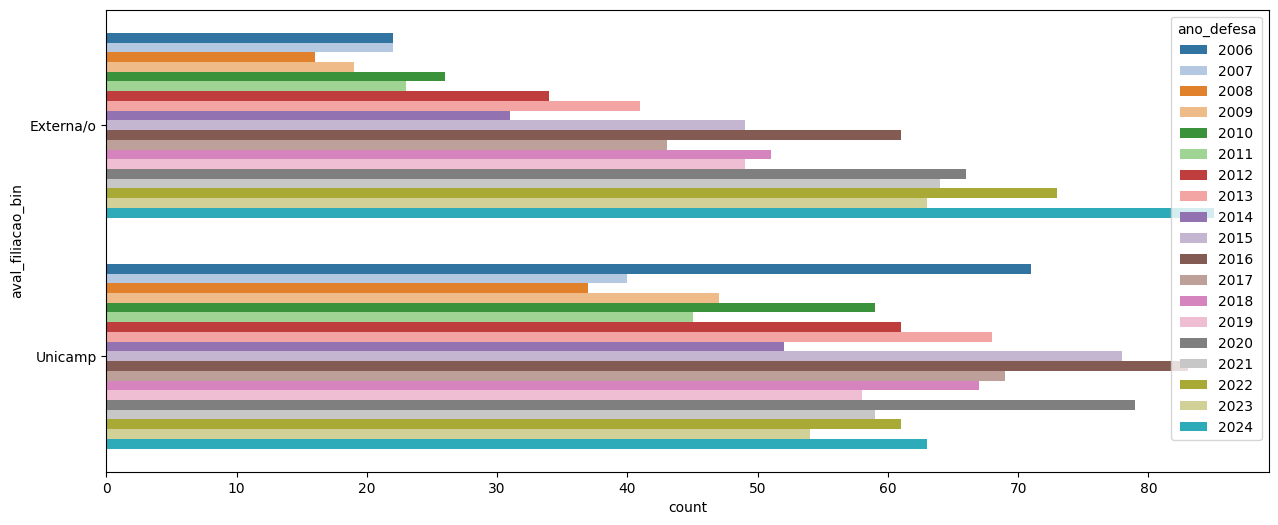

In [58]:
fig, ax = plt.subplots(ncols=1, figsize=(15,6), sharex=True)

sns.countplot(df, y="aval_filiacao_bin", hue="ano_defesa", ax=ax, order=("Externa/o", "Unicamp"), palette="tab20")

In [32]:
infos

{'qtd': 1, 'ano': 2006}

In [25]:
dict_ano = nx.get_edge_attributes(grafo_defesas, name="ano")

In [29]:
grafo_defesas[person1][person2]

AtlasView({0: {'qtd': 1, 'ano': 2006}, 1: {'qtd': 1, 'ano': 2009}, 2: {'qtd': 1, 'ano': 2009}, 3: {'qtd': 1, 'ano': 2010}, 4: {'qtd': 1, 'ano': 2010}, 5: {'qtd': 1, 'ano': 2012}, 6: {'qtd': 1, 'ano': 2013}, 7: {'qtd': 1, 'ano': 2017}, 8: {'qtd': 1, 'ano': 2023}})

In [ ]:
pos = nx.arf_layout(grafo_defesas)

In [82]:
pos = nx.spring_layout(grafo_defesas)

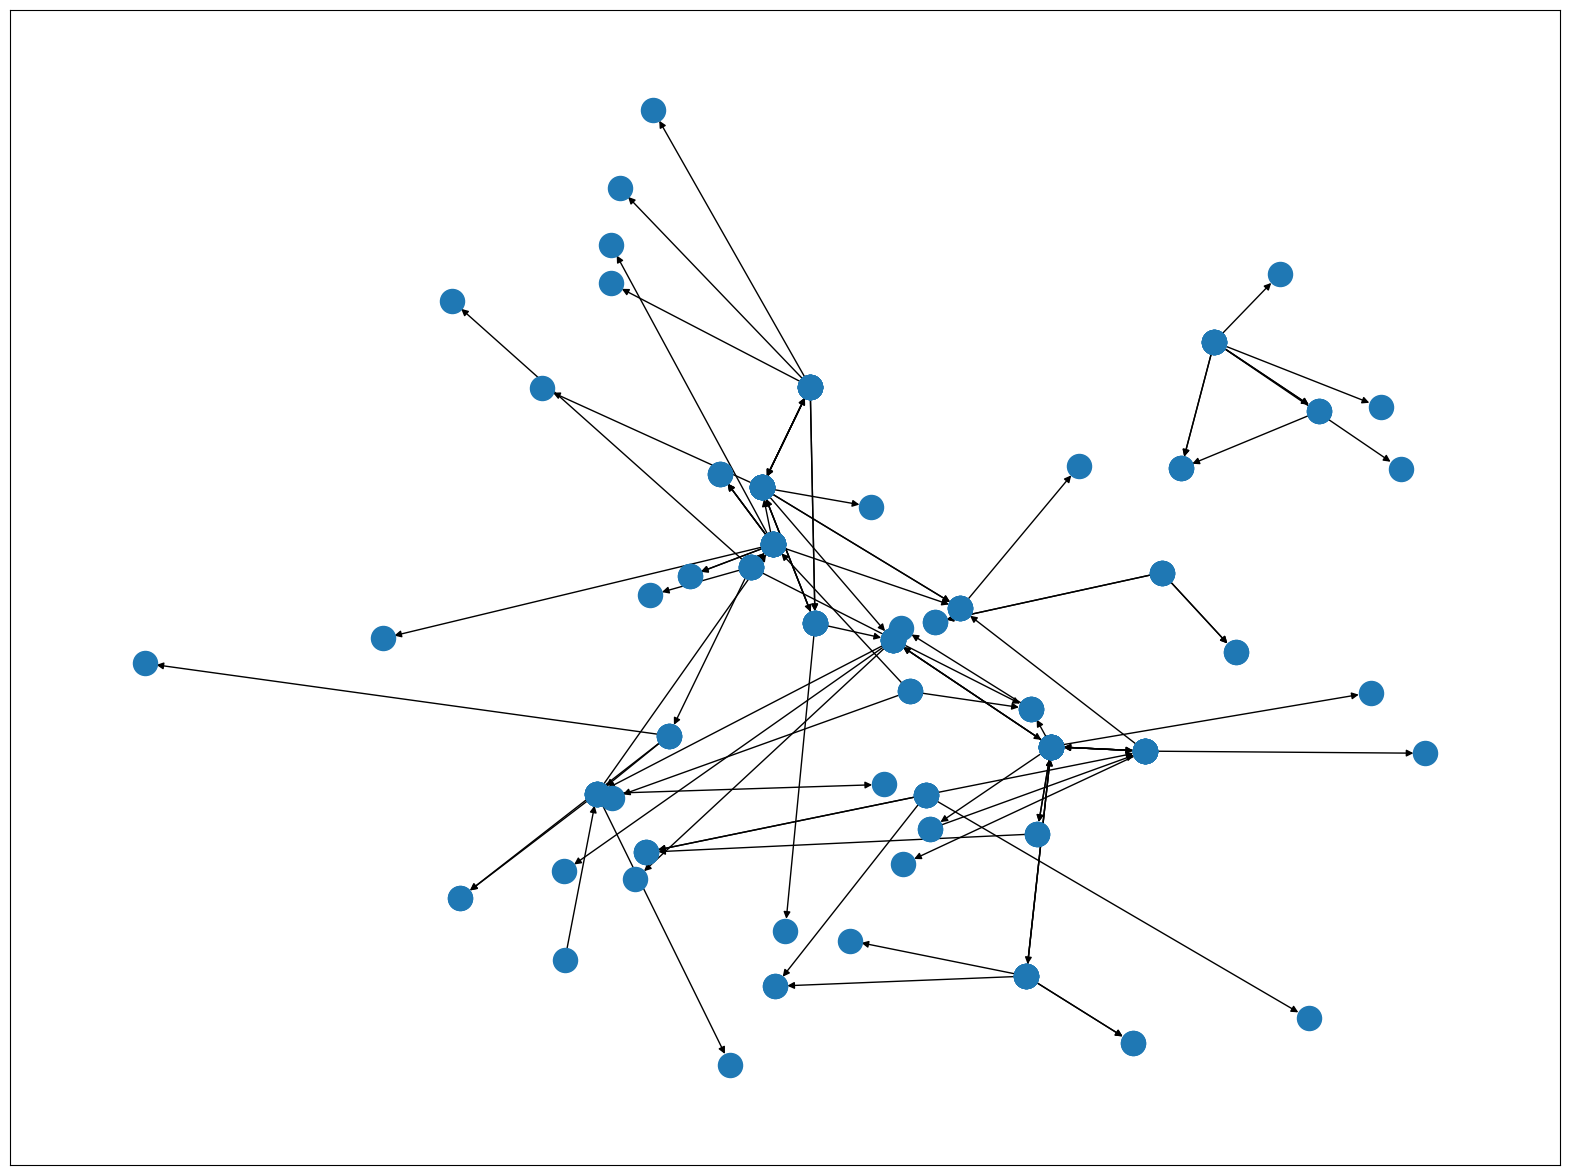

In [83]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
for person1, person2, infos in grafo_defesas.edges(data=True):
    node1 = grafo_defesas.nodes[person1]
    node2 = grafo_defesas.nodes[person2]
    if infos["ano"] != ano: continue
    nos_w_edge_ano.append(person1)
    nos_w_edge_ano.append(person2)
    edge_ano.append((person1, person2))

fig, ax = plt.subplots(ncols=1, figsize=(20,15))
nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=nos_w_edge_ano)
_ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=edge_ano)

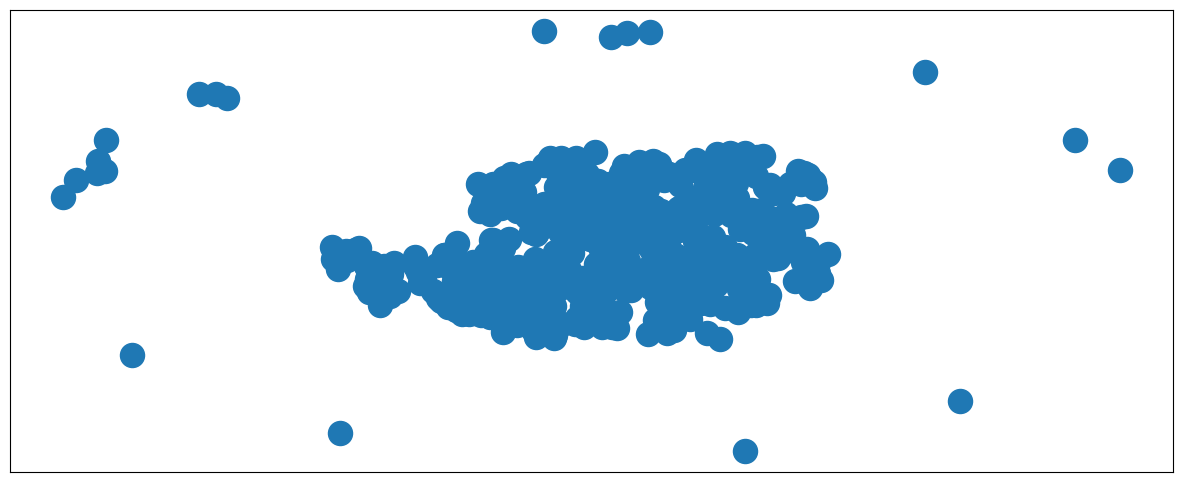

In [84]:
fig, ax = plt.subplots(ncols=1, figsize=(15,6))

nx.draw_networkx_nodes(grafo_defesas, pos=pos)